# Lichens Wavelength Selection Pipeline

This notebook runs the complete wavelength selection and classification pipeline on the Lichens Dataset 1.

**Configuration:**
- Variance-based normalization
- Perturbation dimension (n_important_dimensions) = 1
- n_combinations: 5, 10, 15, 20, 25
- Epochs: 300
- MMR diversity with lambda = 0.5

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path, PosixPath, WindowsPath
import pathlib
from datetime import datetime
from typing import Dict, List, Tuple, Any
from dataclasses import dataclass, asdict
from tqdm.notebook import tqdm
import warnings
import time

warnings.filterwarnings('ignore')

# Workaround for Windows paths in files
pathlib.WindowsPath = pathlib.PosixPath

# Add project root to path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

# Set random seeds
np.random.seed(42)
import random
random.seed(42)
import torch
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print(f"Project root: {project_root}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Project root: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering
Device: CPU


## 1. Configuration

In [ ]:
# =============================================================================
# CONFIGURATION - Modify these as needed
# =============================================================================

# Data paths
DATA_DIR = project_root / "Data" / "processed" / "Lichens Dataset 1"
DATA_FILE = DATA_DIR / "spectra_masked.pkl"
MASK_FILE = DATA_DIR / "class_mask.png"
ROI_FILE = DATA_DIR / "roi_regions.json"

# Output directory
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = project_root / "results" / f"Lichens_Dataset_1_{TIMESTAMP}"

# Sample name
SAMPLE_NAME = "Lichens_Dataset_1"

# =============================================================================
# EXISTING MODEL PATH - Use pre-trained model instead of training each time
# =============================================================================

# Helper function to find existing models
def find_existing_models(results_dir: Path, pattern: str = "Lichens") -> List[Path]:
    """Find all existing model files matching the pattern."""
    models = []
    if results_dir.exists():
        for subdir in sorted(results_dir.iterdir(), reverse=True):  # Most recent first
            if subdir.is_dir() and pattern in subdir.name:
                # Check both possible locations
                for model_subpath in ["model/autoencoder_model.pth", "model_output/*/model.pth"]:
                    for model_file in subdir.glob(model_subpath):
                        if model_file.exists():
                            models.append(model_file)
    return models

# Find available models
available_models = find_existing_models(project_root / "results")
print("Available trained models:")
for i, m in enumerate(available_models[:5]):
    print(f"  [{i}] {m}")
if len(available_models) > 5:
    print(f"  ... and {len(available_models) - 5} more")

# Set the model path - UPDATE THIS TO YOUR MODEL!
# Either use the first found model or specify explicitly:
if available_models:
    EXISTING_MODEL_PATH = available_models[0]  # Use most recent
    print(f"\n→ Using: {EXISTING_MODEL_PATH}")
else:
    EXISTING_MODEL_PATH = project_root / "results" / "YOUR_RUN_FOLDER" / "model" / "autoencoder_model.pth"
    print("\n⚠️  No models found! Update EXISTING_MODEL_PATH manually.")

# Verify paths exist
print("\nChecking paths...")
for name, path in [("Data file", DATA_FILE), ("Mask file", MASK_FILE), ("ROI file", ROI_FILE)]:
    exists = "✓" if path.exists() else "✗ NOT FOUND"
    print(f"  {name}: {exists}")

if EXISTING_MODEL_PATH.exists():
    print(f"  Model: ✓ {EXISTING_MODEL_PATH.name}")
else:
    print(f"  Model: ✗ NOT FOUND at {EXISTING_MODEL_PATH}")

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nOutput directory: {OUTPUT_DIR}")

In [ ]:
# =============================================================================
# PARAMETER SPACE CONFIGURATION
# =============================================================================
# Define each parameter as either:
#   - A single value (will be used for all experiments)
#   - A list of values (will generate combinations)
#
# All combinations of list values will be generated automatically!
# =============================================================================

from itertools import product
from dataclasses import dataclass, field, asdict
from typing import List, Union, Any

@dataclass
class ParameterSpace:
    """Define the parameter space for experiments.
    
    Each parameter can be a single value or a list of values.
    Lists will be combined to generate all possible configurations.
    """
    
    # Selection parameters - CORE
    n_bands_to_select: Union[int, List[int]] = field(
        default_factory=lambda: [5, 10, 15, 20, 25]
    )
    
    # Dimension selection
    dimension_selection_method: Union[str, List[str]] = "variance"  # "variance", "activation", "pca"
    n_important_dimensions: Union[int, List[int]] = 1
    
    # Perturbation settings
    perturbation_method: Union[str, List[str]] = "percentile"  # "percentile", "standard_deviation", "absolute_range"
    perturbation_magnitudes: Union[List[int], List[List[int]]] = field(
        default_factory=lambda: [10, 20, 30]
    )
    
    # Normalization
    normalization_method: Union[str, List[str]] = "variance"  # "variance", "max_per_excitation", "none"
    
    # Diversity constraints
    use_diversity_constraint: Union[bool, List[bool]] = True
    diversity_method: Union[str, List[str]] = "mmr"  # "mmr", "min_distance", "none"
    lambda_diversity: Union[float, List[float]] = 0.5  # 0.0 to 1.0
    min_distance_nm: Union[float, List[float]] = 15.0


def generate_experiment_configs(param_space: ParameterSpace) -> List[dict]:
    """Generate all experiment configurations from parameter space.
    
    Converts single values to lists and generates cartesian product of all parameters.
    """
    # Convert all parameters to lists
    params = {}
    for field_name in ['n_bands_to_select', 'dimension_selection_method', 'n_important_dimensions',
                       'perturbation_method', 'normalization_method', 'use_diversity_constraint',
                       'diversity_method', 'lambda_diversity', 'min_distance_nm']:
        value = getattr(param_space, field_name)
        if not isinstance(value, list):
            params[field_name] = [value]
        else:
            params[field_name] = value
    
    # Handle perturbation_magnitudes specially (it's always a list, could be list of lists)
    pm = param_space.perturbation_magnitudes
    if pm and isinstance(pm[0], list):
        params['perturbation_magnitudes'] = pm
    else:
        params['perturbation_magnitudes'] = [pm]
    
    # Generate all combinations
    keys = list(params.keys())
    values = [params[k] for k in keys]
    
    configs = []
    for combo in product(*values):
        config = dict(zip(keys, combo))
        
        # Skip invalid combinations
        if not config['use_diversity_constraint'] and config['diversity_method'] != 'none':
            # If diversity is disabled but method is set, only keep one variant
            if config['lambda_diversity'] != 0.5:  # Keep only default lambda when diversity disabled
                continue
        
        # Generate config name
        name_parts = [
            f"bands_{config['n_bands_to_select']}",
            f"dim_{config['n_important_dimensions']}",
            f"{config['normalization_method'][:3]}",
        ]
        if config['use_diversity_constraint']:
            name_parts.append(f"{config['diversity_method']}_l{config['lambda_diversity']}")
        else:
            name_parts.append("no_div")
        
        config['name'] = "_".join(name_parts)
        configs.append(config)
    
    return configs


# =============================================================================
# DEFINE YOUR PARAMETER SPACE HERE
# =============================================================================

PARAM_SPACE = ParameterSpace(
    # Number of wavelength bands to select (list = test multiple)
    n_bands_to_select=[5, 10, 15, 20, 25],
    
    # Dimension selection method (single value or list)
    dimension_selection_method="variance",  # Options: "variance", "activation", "pca"
    
    # Number of important latent dimensions to analyze
    n_important_dimensions=1,  # Can be list: [1, 3, 5]
    
    # Perturbation method
    perturbation_method="percentile",  # Options: "percentile", "standard_deviation", "absolute_range"
    
    # Perturbation magnitudes (keep as single list for now)
    perturbation_magnitudes=[10, 20, 30],
    
    # Normalization method
    normalization_method="variance",  # Options: "variance", "max_per_excitation", "none"
    
    # Diversity settings
    use_diversity_constraint=True,  # Can be list: [True, False]
    diversity_method="mmr",         # Options: "mmr", "min_distance", "none". Can be list.
    lambda_diversity=0.5,           # Can be list: [0.3, 0.5, 0.7]
    min_distance_nm=15.0,           # Can be list: [10.0, 15.0, 20.0]
)

# Generate all experiment configurations
EXPERIMENT_CONFIGS = generate_experiment_configs(PARAM_SPACE)

print(f"Generated {len(EXPERIMENT_CONFIGS)} experiment configurations:")
for i, cfg in enumerate(EXPERIMENT_CONFIGS[:10]):  # Show first 10
    print(f"  {i+1}. {cfg['name']}")
if len(EXPERIMENT_CONFIGS) > 10:
    print(f"  ... and {len(EXPERIMENT_CONFIGS) - 10} more")

## 2. Load Data

In [3]:
# Load hyperspectral data using spectral_select
from spectral_select import SpectraData

print("Loading hyperspectral data...")
spectra_data = SpectraData.from_pickle(DATA_FILE)

# Also load as dict for classification
full_data = {
    'excitation_wavelengths': list(spectra_data.excitations.keys()),
    'data': {}
}
for ex_nm, ex_data in spectra_data.excitations.items():
    wavelengths = ex_data.emission_wavelengths
    if hasattr(wavelengths, 'tolist'):
        wavelengths = wavelengths.tolist()
    full_data['data'][str(ex_nm)] = {
        'cube': ex_data.cube,
        'wavelengths': wavelengths
    }

# Get data info
excitations = full_data['excitation_wavelengths']
first_ex = str(excitations[0])
height, width = full_data['data'][first_ex]['cube'].shape[:2]
total_bands = sum(len(full_data['data'][str(ex)]['wavelengths']) for ex in excitations)

print(f"  Excitations: {excitations}")
print(f"  Spatial dimensions: {height} x {width}")
print(f"  Total spectral bands: {total_bands}")

Loading hyperspectral data...
  Excitations: [310.0, 325.0, 340.0, 365.0, 385.0, 400.0, 415.0, 430.0]
  Spatial dimensions: 1040 x 925
  Total spectral bands: 192


In [4]:
# Load ground truth mask
from PIL import Image

print("Loading ground truth mask...")
mask_img = Image.open(MASK_FILE)
mask_array = np.array(mask_img)
print(f"  Mask shape: {mask_array.shape}")

# Load ROI regions
print("\nLoading ROI regions...")
with open(ROI_FILE, 'r') as f:
    roi_data = json.load(f)

print(f"  Classes: {len(roi_data['classes'])}")
for cls in roi_data['classes']:
    print(f"    - {cls['name']} (id={cls['id']}): color={cls['color']}")

print(f"\n  ROI Regions: {len(roi_data['regions'])}")
for roi in roi_data['regions']:
    rect = roi['rect']
    print(f"    - {roi['class_name']}: rows [{rect['row_min']}, {rect['row_max']}], cols [{rect['col_min']}, {rect['col_max']}]")

Loading ground truth mask...
  Mask shape: (1040, 925, 3)

Loading ROI regions...
  Classes: 4
    - Class 1 (id=1): color=[255, 0, 0]
    - Class 3 (id=3): color=[0, 0, 255]
    - Class 6 (id=6): color=[0, 200, 0]
    - Class 7 (id=7): color=[255, 165, 0]

  ROI Regions: 4
    - Class 1: rows [185, 234], cols [53, 112]
    - Class 3: rows [183, 232], cols [229, 288]
    - Class 6: rows [178, 227], cols [454, 513]
    - Class 7: rows [182, 231], cols [667, 726]


## 3. Prepare Ground Truth and ROIs

In [5]:
# Extract ground truth labels from mask
def extract_ground_truth(mask_array, roi_data):
    """Convert RGB mask to class labels using ROI data."""
    ground_truth = np.full(mask_array.shape[:2], -1, dtype=int)
    class_colors = {}
    
    # Build color to class mapping
    for cls in roi_data['classes']:
        color = tuple(cls['color'])
        class_id = cls['id']
        class_colors[color] = class_id
    
    # Assign labels
    for color, class_id in class_colors.items():
        if mask_array.shape[-1] == 4:  # RGBA
            mask = np.all(mask_array[:, :, :3] == color, axis=2)
        else:  # RGB
            mask = np.all(mask_array == color, axis=2)
        ground_truth[mask] = class_id
        pixel_count = np.sum(mask)
        print(f"  Class {class_id}: {pixel_count:,} pixels")
    
    return ground_truth, class_colors

print("Extracting ground truth labels...")
ground_truth, class_colors = extract_ground_truth(mask_array, roi_data)
print(f"\n  Ground truth shape: {ground_truth.shape}")
print(f"  Unique labels: {np.unique(ground_truth)}")

Extracting ground truth labels...
  Class 1: 57,947 pixels
  Class 3: 37,852 pixels
  Class 6: 56,090 pixels
  Class 7: 39,157 pixels

  Ground truth shape: (1040, 925)
  Unique labels: [-1  1  3  6  7]


In [6]:
# Create ROI regions dataclass
@dataclass
class ROIRegion:
    name: str
    coords: Tuple[int, int, int, int]  # (row_min, row_max, col_min, col_max)
    color: str
    class_id: int

# Convert ROI data to ROIRegion objects
roi_regions = []
color_map = {cls['id']: '#{:02x}{:02x}{:02x}'.format(*cls['color']) for cls in roi_data['classes']}

for roi in roi_data['regions']:
    rect = roi['rect']
    roi_regions.append(ROIRegion(
        name=roi['class_name'],
        coords=(rect['row_min'], rect['row_max'], rect['col_min'], rect['col_max']),
        color=color_map[roi['class_id']],
        class_id=roi['class_id']
    ))

print(f"Created {len(roi_regions)} ROI regions:")
for roi in roi_regions:
    print(f"  {roi.name} (class {roi.class_id}): {roi.coords}")

Created 4 ROI regions:
  Class 1 (class 1): (185, 234, 53, 112)
  Class 3 (class 3): (183, 232, 229, 288)
  Class 6 (class 6): (178, 227, 454, 513)
  Class 7 (class 7): (182, 231, 667, 726)


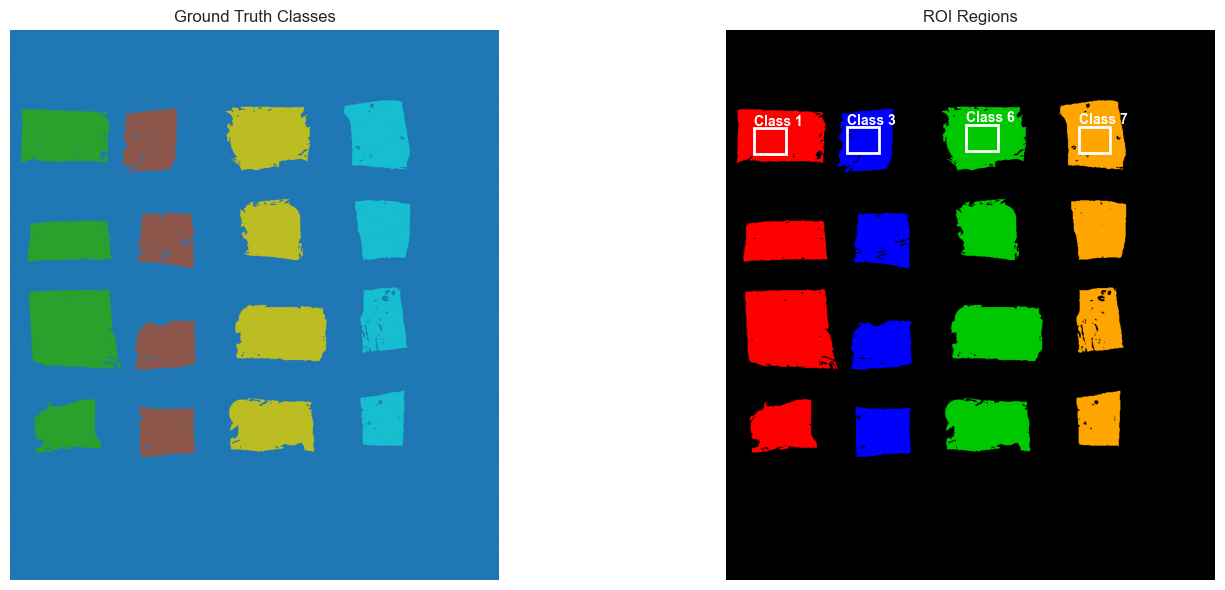

In [7]:
 # Visualize ground truth and ROIs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ground truth
ax = axes[0]
ax.imshow(ground_truth, cmap='tab10')
ax.set_title('Ground Truth Classes')
ax.axis('off')

# ROI regions overlay
ax = axes[1]
ax.imshow(mask_array)
for roi in roi_regions:
    row_min, row_max, col_min, col_max = roi.coords
    rect = plt.Rectangle((col_min, row_min), col_max - col_min, row_max - row_min,
                         fill=False, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(col_min, row_min - 5, roi.name, color='white', fontsize=10, fontweight='bold')
ax.set_title('ROI Regions')
ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ground_truth_and_rois.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Create Analysis Mask

In [8]:
# Create binary analysis mask (non-background pixels)
analysis_mask = ground_truth >= 0
print(f"Analysis mask: {np.sum(analysis_mask):,} valid pixels out of {analysis_mask.size:,}")

# Save mask for wavelength selection
mask_path = OUTPUT_DIR / 'analysis_mask.npy'
np.save(mask_path, analysis_mask)
print(f"Saved analysis mask to: {mask_path}")

# Create model directory
model_dir = OUTPUT_DIR / 'model'
model_dir.mkdir(exist_ok=True)
model_path = model_dir / 'autoencoder_model.pth'

Analysis mask: 191,046 valid pixels out of 962,000
Saved analysis mask to: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/results/Lichens_Dataset_1_20260129_130746/analysis_mask.npy


## 5. Import Modules and Define Helpers

In [ ]:
class PerformanceTimer:
    """Context manager for timing operations."""
    def __init__(self):
        self.elapsed = 0
    def __enter__(self):
        self.start = time.time()
        return self
    def __exit__(self, *args):
        self.elapsed = time.time() - self.start


def run_wavelength_selection_with_existing_model(
    data_file: Path,
    mask_path: Path, 
    model_path: Path,
    output_dir: Path,
    sample_name: str,
    exp_config: dict
) -> Tuple[List[dict], Any]:
    """Run wavelength selection using an EXISTING trained model.
    
    Args:
        data_file: Path to spectral data pickle
        mask_path: Path to analysis mask
        model_path: Path to pre-trained autoencoder model (.pth file)
        output_dir: Output directory for this experiment
        sample_name: Sample identifier
        exp_config: Experiment configuration dictionary from parameter space
        
    Returns:
        Tuple of (wavelength_combinations list, analyzer object)
    """
    
    # Create config using experiment parameters
    config = Config(
        sample_name=sample_name,
        data_path=str(data_file),
        mask_path=str(mask_path),
        model_path=str(model_path),  # Use existing model!
        output_dir=str(output_dir),
        
        # Selection parameters from exp_config
        n_bands_to_select=exp_config['n_bands_to_select'],
        n_important_dimensions=exp_config['n_important_dimensions'],
        
        # Dimension selection
        dimension_selection_method=exp_config['dimension_selection_method'],
        
        # Perturbation
        perturbation_method=exp_config['perturbation_method'],
        perturbation_magnitudes=exp_config['perturbation_magnitudes'],
        
        # Normalization
        normalization_method=exp_config['normalization_method'],
        
        # Diversity
        use_diversity_constraint=exp_config['use_diversity_constraint'],
        diversity_method=exp_config['diversity_method'],
        lambda_diversity=exp_config['lambda_diversity'],
        min_distance_nm=exp_config['min_distance_nm'],
        
        # Don't train - we have an existing model
        training_epochs=1,  # Minimal, won't be used if model exists
        
        # Output settings
        save_visualizations=False,
        save_tiff_layers=False,
    )
    
    # Run analysis
    analyzer = Analyzer(config)
    
    # Load data
    spectra = SpectraData.from_pickle(data_file)
    spectra.mask = np.load(mask_path)
    
    # Fit analyzer (will load existing model)
    analyzer.fit(spectra)
    
    # Get result
    result = analyzer.result
    if result is None:
        raise ValueError("Analyzer fit() did not produce a result")
    
    # Convert to wavelength combinations format
    wavelength_combinations = []
    for band in result.selected_bands:
        wavelength_combinations.append({
            'excitation': float(band.excitation_nm),
            'emission': float(band.emission_nm),
            'combination_name': f"Ex{band.excitation_nm:.0f}_Em{band.emission_nm:.1f}",
            'influence_score': float(band.influence_score),
            'rank': int(band.rank)
        })
    
    return wavelength_combinations, analyzer


def extract_wavelength_subset(full_data, wavelength_combinations):
    """Extract subset of data using selected wavelength combinations."""
    subset_data = {
        'data': {},
        'excitation_wavelengths': [],
    }
    
    # Group by excitation
    combos_by_ex = {}
    for combo in wavelength_combinations:
        ex = combo['excitation']
        if ex not in combos_by_ex:
            combos_by_ex[ex] = []
        combos_by_ex[ex].append(combo['emission'])
    
    total_original = 0
    total_selected = 0
    
    for ex in full_data['excitation_wavelengths']:
        ex_str = str(ex)
        ex_data = full_data['data'][ex_str]
        wavelengths = np.array(ex_data['wavelengths'])
        cube = ex_data['cube']
        total_original += len(wavelengths)
        
        # Find matching emissions
        matching = None
        for combo_ex, emissions in combos_by_ex.items():
            if abs(float(ex) - float(combo_ex)) < 1.0:
                matching = emissions
                break
        
        if matching is None:
            continue
        
        # Select bands
        indices = []
        wl_values = []
        for em in matching:
            distances = np.abs(wavelengths - float(em))
            idx = np.argmin(distances)
            if distances[idx] < 10 and idx not in indices:
                indices.append(idx)
                wl_values.append(wavelengths[idx])
        
        if indices:
            subset_data['data'][ex_str] = {
                'cube': cube[:, :, indices],
                'wavelengths': wl_values
            }
            subset_data['excitation_wavelengths'].append(ex)
            total_selected += len(indices)
    
    reduction = (1 - total_selected / total_original) * 100 if total_original > 0 else 0
    print(f"  Data: {total_original} -> {total_selected} bands ({reduction:.1f}% reduction)")
    
    return subset_data


def run_knn_classification(data, roi_regions, ground_truth, n_neighbors=5):
    """Run KNN classification using ROI regions as training data.
    
    Only processes valid (non-masked) pixels where ground_truth >= 0.
    """
    
    first_ex = str(data['excitation_wavelengths'][0])
    height, width = data['data'][first_ex]['cube'].shape[:2]
    
    # Create valid pixel mask (only where ground truth is labeled)
    valid_mask = ground_truth >= 0
    valid_coords = np.argwhere(valid_mask)  # (N, 2) array of [y, x] coordinates
    
    print(f"  Valid pixels: {len(valid_coords):,} out of {height * width:,}")
    
    # Build feature matrix ONLY for valid pixels
    features = []
    for y, x in valid_coords:
        pixel = []
        for ex in data['excitation_wavelengths']:
            cube = data['data'][str(ex)]['cube']
            pixel.extend(cube[y, x, :])
        features.append(pixel)
    
    X_full = np.array(features)
    n_features = X_full.shape[1]
    
    # Check for any remaining NaNs (shouldn't happen, but just in case)
    if np.any(np.isnan(X_full)):
        nan_count = np.sum(np.isnan(X_full))
        print(f"  Warning: {nan_count} NaN values found in valid pixels, replacing with 0")
        X_full = np.nan_to_num(X_full, nan=0.0)
    
    # Extract training data from ROIs
    X_train, y_train = [], []
    for roi in roi_regions:
        row_min, row_max, col_min, col_max = roi.coords
        for y in range(row_min, row_max):
            for x in range(col_min, col_max):
                if 0 <= y < height and 0 <= x < width and valid_mask[y, x]:
                    # Find index in valid_coords
                    idx = np.where((valid_coords[:, 0] == y) & (valid_coords[:, 1] == x))[0]
                    if len(idx) > 0:
                        X_train.append(X_full[idx[0]])
                        y_train.append(roi.class_id)
    
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    print(f"  Training: {len(X_train)} samples, {len(np.unique(y_train))} classes")
    
    # Scale and train
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_full_scaled = scaler.transform(X_full)
    
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    predictions = knn.predict(X_full_scaled)
    
    # Reconstruct map (only valid pixels get predictions)
    cluster_map = np.full((height, width), -1, dtype=int)
    for i, (y, x) in enumerate(valid_coords):
        cluster_map[y, x] = predictions[i]
    
    # Calculate metrics (only on valid pixels)
    y_true = ground_truth[valid_mask]
    y_pred = cluster_map[valid_mask]
    
    metrics = {
        'n_features': n_features,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
        'ari': adjusted_rand_score(y_true, y_pred),
        'nmi': normalized_mutual_info_score(y_true, y_pred),
    }
    
    return cluster_map, metrics


print("Helper functions defined")
print(f"  - run_wavelength_selection_with_existing_model()")
print(f"  - extract_wavelength_subset()")
print(f"  - run_knn_classification()")

In [10]:
class PerformanceTimer:
    """Context manager for timing operations."""
    def __init__(self):
        self.elapsed = 0
    def __enter__(self):
        self.start = time.time()
        return self
    def __exit__(self, *args):
        self.elapsed = time.time() - self.start


def run_wavelength_selection(data_file, mask_path, sample_name, n_bands, model_path, output_dir):
    """Run wavelength selection using spectral_select module."""
    
    # Create config
    config = Config(
        sample_name=sample_name,
        data_path=str(data_file),
        mask_path=str(mask_path),
        model_path=str(model_path),
        output_dir=str(output_dir),
        n_bands_to_select=n_bands,
        n_important_dimensions=N_IMPORTANT_DIMENSIONS,
        use_diversity_constraint=USE_DIVERSITY,
        diversity_method=DIVERSITY_METHOD,
        lambda_diversity=LAMBDA_DIVERSITY,
        normalization_method='variance',
        training_epochs=N_EPOCHS,
        training_early_stopping_patience=5,
        # training_scheduler_patience=5,
        save_visualizations=False,
        save_tiff_layers=False,
    )
    
    # Run analysis
    analyzer = Analyzer(config)
    
    # Load data
    spectra = SpectraData.from_pickle(data_file)
    spectra.mask = np.load(mask_path)
    
    # Fit analyzer
    analyzer.fit(spectra)
    
    # Get result
    result = analyzer.result
    if result is None:
        raise ValueError("Analyzer fit() did not produce a result")
    
    # Convert to wavelength combinations format
    wavelength_combinations = []
    for band in result.selected_bands:
        wavelength_combinations.append({
            'excitation': float(band.excitation_nm),
            'emission': float(band.emission_nm),
            'combination_name': f"Ex{band.excitation_nm:.0f}_Em{band.emission_nm:.1f}",
            'influence_score': float(band.influence_score),
            'rank': int(band.rank)
        })
    
    return wavelength_combinations, analyzer


def extract_wavelength_subset(full_data, wavelength_combinations):
    """Extract subset of data using selected wavelength combinations."""
    subset_data = {
        'data': {},
        'excitation_wavelengths': [],
    }
    
    # Group by excitation
    combos_by_ex = {}
    for combo in wavelength_combinations:
        ex = combo['excitation']
        if ex not in combos_by_ex:
            combos_by_ex[ex] = []
        combos_by_ex[ex].append(combo['emission'])
    
    total_original = 0
    total_selected = 0
    
    for ex in full_data['excitation_wavelengths']:
        ex_str = str(ex)
        ex_data = full_data['data'][ex_str]
        wavelengths = np.array(ex_data['wavelengths'])
        cube = ex_data['cube']
        total_original += len(wavelengths)
        
        # Find matching emissions
        matching = None
        for combo_ex, emissions in combos_by_ex.items():
            if abs(float(ex) - float(combo_ex)) < 1.0:
                matching = emissions
                break
        
        if matching is None:
            continue
        
        # Select bands
        indices = []
        wl_values = []
        for em in matching:
            distances = np.abs(wavelengths - float(em))
            idx = np.argmin(distances)
            if distances[idx] < 10 and idx not in indices:
                indices.append(idx)
                wl_values.append(wavelengths[idx])
        
        if indices:
            subset_data['data'][ex_str] = {
                'cube': cube[:, :, indices],
                'wavelengths': wl_values
            }
            subset_data['excitation_wavelengths'].append(ex)
            total_selected += len(indices)
    
    reduction = (1 - total_selected / total_original) * 100 if total_original > 0 else 0
    print(f"  Data: {total_original} -> {total_selected} bands ({reduction:.1f}% reduction)")
    
    return subset_data


def run_knn_classification(data, roi_regions, ground_truth, n_neighbors=5):
    """Run KNN classification using ROI regions as training data.
    
    Only processes valid (non-masked) pixels where ground_truth >= 0.
    """
    
    first_ex = str(data['excitation_wavelengths'][0])
    height, width = data['data'][first_ex]['cube'].shape[:2]
    
    # Create valid pixel mask (only where ground truth is labeled)
    valid_mask = ground_truth >= 0
    valid_coords = np.argwhere(valid_mask)  # (N, 2) array of [y, x] coordinates
    
    print(f"  Valid pixels: {len(valid_coords):,} out of {height * width:,}")
    
    # Build feature matrix ONLY for valid pixels
    features = []
    for y, x in valid_coords:
        pixel = []
        for ex in data['excitation_wavelengths']:
            cube = data['data'][str(ex)]['cube']
            pixel.extend(cube[y, x, :])
        features.append(pixel)
    
    X_full = np.array(features)
    n_features = X_full.shape[1]
    
    # Check for any remaining NaNs (shouldn't happen, but just in case)
    if np.any(np.isnan(X_full)):
        nan_count = np.sum(np.isnan(X_full))
        print(f"  Warning: {nan_count} NaN values found in valid pixels, replacing with 0")
        X_full = np.nan_to_num(X_full, nan=0.0)
    
    # Extract training data from ROIs
    X_train, y_train = [], []
    for roi in roi_regions:
        row_min, row_max, col_min, col_max = roi.coords
        for y in range(row_min, row_max):
            for x in range(col_min, col_max):
                if 0 <= y < height and 0 <= x < width and valid_mask[y, x]:
                    # Find index in valid_coords
                    idx = np.where((valid_coords[:, 0] == y) & (valid_coords[:, 1] == x))[0]
                    if len(idx) > 0:
                        X_train.append(X_full[idx[0]])
                        y_train.append(roi.class_id)
    
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    print(f"  Training: {len(X_train)} samples, {len(np.unique(y_train))} classes")
    
    # Scale and train
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_full_scaled = scaler.transform(X_full)
    
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
    knn.fit(X_train_scaled, y_train)
    predictions = knn.predict(X_full_scaled)
    
    # Reconstruct map (only valid pixels get predictions)
    cluster_map = np.full((height, width), -1, dtype=int)
    for i, (y, x) in enumerate(valid_coords):
        cluster_map[y, x] = predictions[i]
    
    # Calculate metrics (only on valid pixels)
    y_true = ground_truth[valid_mask]
    y_pred = cluster_map[valid_mask]
    
    metrics = {
        'n_features': n_features,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
        'ari': adjusted_rand_score(y_true, y_pred),
        'nmi': normalized_mutual_info_score(y_true, y_pred),
    }
    
    return cluster_map, metrics


print("Helper functions defined")

Helper functions defined


## 6. Run Baseline Classification (Full Data)

In [11]:
print("="*80)
print("BASELINE: Full Data Classification")
print("="*80)

with PerformanceTimer() as baseline_timer:
    cluster_map_baseline, metrics_baseline = run_knn_classification(
        full_data, roi_regions, ground_truth
    )

print(f"\nBaseline Results:")
print(f"  Features: {metrics_baseline['n_features']}")
print(f"  Accuracy: {metrics_baseline['accuracy']:.4f}")
print(f"  F1 Score: {metrics_baseline['f1']:.4f}")
print(f"  Cohen's Kappa: {metrics_baseline['kappa']:.4f}")
print(f"  Time: {baseline_timer.elapsed:.2f}s")

BASELINE: Full Data Classification
  Valid pixels: 191,046 out of 962,000
  Training: 11519 samples, 4 classes

Baseline Results:
  Features: 192
  Accuracy: 0.8815
  F1 Score: 0.8824
  Cohen's Kappa: 0.8416
  Time: 5.16s


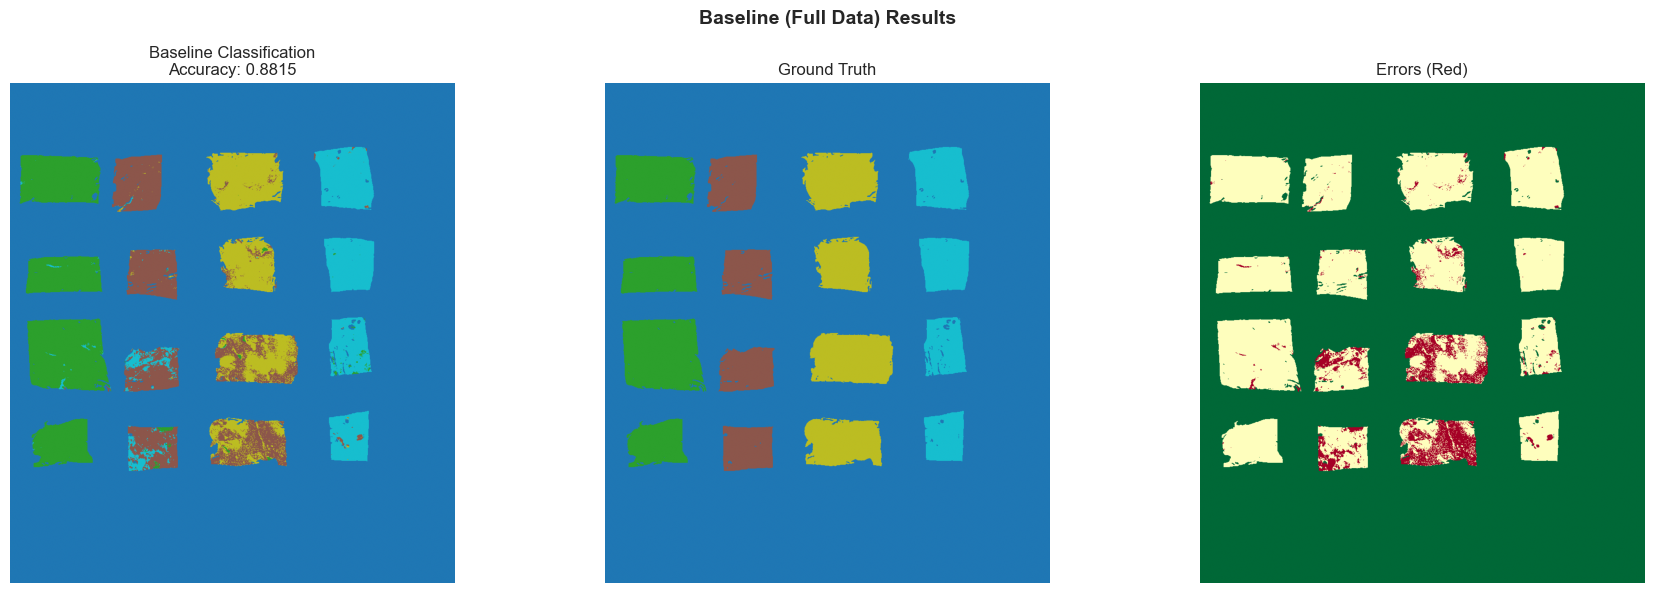

In [12]:
# Visualize baseline results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Classification
axes[0].imshow(cluster_map_baseline, cmap='tab10')
axes[0].set_title(f'Baseline Classification\nAccuracy: {metrics_baseline["accuracy"]:.4f}')
axes[0].axis('off')

# Ground truth
axes[1].imshow(ground_truth, cmap='tab10')
axes[1].set_title('Ground Truth')
axes[1].axis('off')

# Difference
diff = (cluster_map_baseline != ground_truth).astype(int)
diff[ground_truth < 0] = -1
axes[2].imshow(diff, cmap='RdYlGn_r', vmin=-1, vmax=1)
axes[2].set_title('Errors (Red)')
axes[2].axis('off')

plt.suptitle('Baseline (Full Data) Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Store all results
results = [{
    'config': 'BASELINE',
    'n_bands_selected': total_bands,
    'n_features': metrics_baseline['n_features'],
    'reduction_pct': 0.0,
    **metrics_baseline,
    'selection_time': 0.0,
    'classification_time': baseline_timer.elapsed
}]

all_cluster_maps = {'BASELINE': cluster_map_baseline}
all_wavelength_combinations = {}

# Verify existing model
if not EXISTING_MODEL_PATH.exists():
    print("⚠️  WARNING: Existing model not found!")
    print(f"   Path: {EXISTING_MODEL_PATH}")
    print("   Please update EXISTING_MODEL_PATH in the configuration cell.")
    print("   Looking for available models in results folder...")
    
    # Try to find any model
    results_dir = project_root / "results"
    if results_dir.exists():
        for subdir in results_dir.iterdir():
            if subdir.is_dir() and "Lichens" in subdir.name:
                model_file = subdir / "model" / "autoencoder_model.pth"
                if model_file.exists():
                    print(f"   Found: {model_file}")
else:
    print(f"✓ Using existing model: {EXISTING_MODEL_PATH}")

print(f"\nRunning {len(EXPERIMENT_CONFIGS)} experiment configurations...")
print(f"Parameter space summary:")
print(f"  - n_bands: {PARAM_SPACE.n_bands_to_select}")
print(f"  - dimension_selection: {PARAM_SPACE.dimension_selection_method}")
print(f"  - n_important_dims: {PARAM_SPACE.n_important_dimensions}")
print(f"  - normalization: {PARAM_SPACE.normalization_method}")
print(f"  - diversity: {PARAM_SPACE.diversity_method} (lambda={PARAM_SPACE.lambda_diversity})")

In [ ]:
for i, exp_config in enumerate(tqdm(EXPERIMENT_CONFIGS, desc="Running experiments")):
    config_name = exp_config['name']
    print(f"\n{'='*60}")
    print(f"[{i+1}/{len(EXPERIMENT_CONFIGS)}] Configuration: {config_name}")
    print(f"{'='*60}")
    print(f"  n_bands: {exp_config['n_bands_to_select']}, dims: {exp_config['n_important_dimensions']}")
    print(f"  diversity: {exp_config['diversity_method']} (lambda={exp_config['lambda_diversity']})")
    
    exp_dir = OUTPUT_DIR / 'experiments' / config_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    
    try:
        # Run wavelength selection with existing model
        print(f"\n1. Wavelength Selection...")
        with PerformanceTimer() as sel_timer:
            wavelength_combos, analyzer = run_wavelength_selection_with_existing_model(
                data_file=DATA_FILE,
                mask_path=mask_path,
                model_path=EXISTING_MODEL_PATH,
                output_dir=exp_dir / 'wavelength_selection',
                sample_name=SAMPLE_NAME,
                exp_config=exp_config
            )
        print(f"  Selected {len(wavelength_combos)} bands in {sel_timer.elapsed:.2f}s")
        all_wavelength_combinations[config_name] = wavelength_combos
        
        # Save wavelength combinations
        with open(exp_dir / f'{config_name}_wavelengths.json', 'w') as f:
            json.dump(wavelength_combos, f, indent=2)
        
        # Save experiment config
        with open(exp_dir / f'{config_name}_config.json', 'w') as f:
            json.dump(exp_config, f, indent=2)
        
        # Extract subset
        print(f"\n2. Extracting data subset...")
        subset_data = extract_wavelength_subset(full_data, wavelength_combos)
        
        # Run classification
        print(f"\n3. KNN Classification...")
        with PerformanceTimer() as cls_timer:
            cluster_map, metrics = run_knn_classification(
                subset_data, roi_regions, ground_truth
            )
        all_cluster_maps[config_name] = cluster_map
        
        # Calculate reduction
        reduction = (1 - metrics['n_features'] / metrics_baseline['n_features']) * 100
        speedup = baseline_timer.elapsed / cls_timer.elapsed if cls_timer.elapsed > 0 else 0
        
        print(f"\nResults:")
        print(f"  Features: {metrics['n_features']} ({reduction:.1f}% reduction)")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  F1 Score: {metrics['f1']:.4f}")
        print(f"  Kappa: {metrics['kappa']:.4f}")
        print(f"  Classification time: {cls_timer.elapsed:.2f}s")
        
        # Store results with full config info
        results.append({
            'config': config_name,
            'n_bands_selected': len(wavelength_combos),
            'n_features': metrics['n_features'],
            'reduction_pct': reduction,
            # Config parameters
            'n_bands_to_select': exp_config['n_bands_to_select'],
            'n_important_dimensions': exp_config['n_important_dimensions'],
            'dimension_selection_method': exp_config['dimension_selection_method'],
            'normalization_method': exp_config['normalization_method'],
            'use_diversity': exp_config['use_diversity_constraint'],
            'diversity_method': exp_config['diversity_method'],
            'lambda_diversity': exp_config['lambda_diversity'],
            # Metrics
            **metrics,
            'selection_time': sel_timer.elapsed,
            'classification_time': cls_timer.elapsed,
            'speedup': speedup
        })
        
        # Save visualization
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(cluster_map, cmap='tab10')
        ax.set_title(f'{config_name}\nAccuracy: {metrics["accuracy"]:.4f}, F1: {metrics["f1"]:.4f}')
        ax.axis('off')
        plt.savefig(exp_dir / f'{config_name}_classification.png', dpi=150, bbox_inches='tight')
        plt.close()
        
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()
        results.append({
            'config': config_name,
            'error': str(e),
            **{k: v for k, v in exp_config.items() if k != 'name'}
        })

In [14]:
for n_bands in tqdm(N_BANDS_LIST, desc="Running experiments"):
    config_name = f"bands_{n_bands}_mmr_0.5"
    print(f"\n{'='*60}")
    print(f"Configuration: {config_name}")
    print(f"{'='*60}")
    
    exp_dir = OUTPUT_DIR / 'experiments' / config_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    
    try:
        # Run wavelength selection
        print(f"\n1. Wavelength Selection (n_bands={n_bands})...")
        with PerformanceTimer() as sel_timer:
            wavelength_combos, analyzer = run_wavelength_selection(
                DATA_FILE, mask_path, SAMPLE_NAME, n_bands, model_path,
                exp_dir / 'wavelength_selection'
            )
        print(f"  Selected {len(wavelength_combos)} bands in {sel_timer.elapsed:.2f}s")
        all_wavelength_combinations[config_name] = wavelength_combos
        
        # Save wavelength combinations
        with open(exp_dir / f'{config_name}_wavelengths.json', 'w') as f:
            json.dump(wavelength_combos, f, indent=2)
        
        # Extract subset
        print(f"\n2. Extracting data subset...")
        subset_data = extract_wavelength_subset(full_data, wavelength_combos)
        
        # Run classification
        print(f"\n3. KNN Classification...")
        with PerformanceTimer() as cls_timer:
            cluster_map, metrics = run_knn_classification(
                subset_data, roi_regions, ground_truth
            )
        all_cluster_maps[config_name] = cluster_map
        
        # Calculate reduction
        reduction = (1 - metrics['n_features'] / metrics_baseline['n_features']) * 100
        speedup = baseline_timer.elapsed / cls_timer.elapsed if cls_timer.elapsed > 0 else 0
        
        print(f"\nResults:")
        print(f"  Features: {metrics['n_features']} ({reduction:.1f}% reduction)")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  F1 Score: {metrics['f1']:.4f}")
        print(f"  Kappa: {metrics['kappa']:.4f}")
        print(f"  Classification time: {cls_timer.elapsed:.2f}s (speedup: {speedup:.2f}x)")
        
        # Store results
        results.append({
            'config': config_name,
            'n_bands_selected': len(wavelength_combos),
            'n_features': metrics['n_features'],
            'reduction_pct': reduction,
            **metrics,
            'selection_time': sel_timer.elapsed,
            'classification_time': cls_timer.elapsed,
            'speedup': speedup
        })
        
        # Save visualization
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(cluster_map, cmap='tab10')
        ax.set_title(f'{config_name}\nAccuracy: {metrics["accuracy"]:.4f}, F1: {metrics["f1"]:.4f}')
        ax.axis('off')
        plt.savefig(exp_dir / f'{config_name}_classification.png', dpi=150, bbox_inches='tight')
        plt.close()
        
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()
        results.append({
            'config': config_name,
            'error': str(e)
        })

Running experiments:   0%|          | 0/5 [00:00<?, ?it/s]


Configuration: bands_5_mmr_0.5

1. Wavelength Selection (n_bands=5)...
Preparing data for 8 excitation wavelengths...
Emission band lengths for each excitation wavelength:
  - Excitation 310.0 nm: 22 bands
  - Excitation 325.0 nm: 22 bands
  - Excitation 340.0 nm: 22 bands
  - Excitation 365.0 nm: 27 bands
  - Excitation 385.0 nm: 28 bands
  - Excitation 400.0 nm: 25 bands
  - Excitation 415.0 nm: 24 bands
  - Excitation 430.0 nm: 22 bands
Mask processed. Valid pixels: 191046.0/962000 (19.86%)
Global data range (valid values only): [0.0000, 4027.0000]
Data normalized to range [0, 1] using global normalization
Data preparation complete. Spatial dimensions: 1040x925


Training new autoencoder model. This may take several minutes...


Creating spatial chunks for each excitation wavelength...
Created 323 chunks for each excitation
Starting training for 10 epochs with 323 batches...
Epoch 1/10, Loss: 0.3746 (Recon: 0.0104, Sparsity: 0.3642), Time: 48.10s
  New best model saved to /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/results/Lichens_Dataset_1_20260129_130746/model/best_hyperspectral_model.pth (loss: 0.3746)
Epoch 2/10, Loss: 0.0018 (Recon: 0.0015, Sparsity: 0.0003), Time: 43.56s
  New best model saved to /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/results/Lichens_Dataset_1_20260129_130746/model/best_hyperspectral_model.pth (loss: 0.0018)
Epoch 3/10, Loss: 0.0017 (Recon: 0.0014, Sparsity: 0.0003), Time: 718.71s
  New best model saved to /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/results/Lichens_Dataset_1_20260129_130746/model/best_hyperspectral_model.pth (loss: 0.0017)
Epoch 4/10, Loss: 0.0017 (Recon: 0.0014, Spars

## 8. Save and Analyze Results

In [15]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('accuracy', ascending=False, na_position='last')

# Display results
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
display(results_df[['config', 'n_features', 'reduction_pct', 'accuracy', 'f1', 'kappa', 'classification_time']].round(4))


RESULTS SUMMARY


,config,n_features,reduction_pct,accuracy,f1,kappa,classification_time
0,BASELINE,192,0.0000,0.8815,0.8824,0.8416,5.1584
5,bands_25_mmr_0.5,25,86.9792,0.7718,0.7728,0.6940,2.1707
4,bands_20_mmr_0.5,20,89.5833,0.7580,0.7592,0.6753,2.0692
3,bands_15_mmr_0.5,15,92.1875,0.6802,0.6835,0.5716,7.7317
2,bands_10_mmr_0.5,10,94.7917,0.6181,0.6256,0.4906,4.9962
1,bands_5_mmr_0.5,5,97.3958,0.4343,0.4299,0.2390,3.5679


In [16]:
# Save to Excel
excel_path = OUTPUT_DIR / 'results.xlsx'
results_df.to_excel(excel_path, index=False)
print(f"Results saved to: {excel_path}")

# Save to CSV
csv_path = OUTPUT_DIR / 'results.csv'
results_df.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")

Results saved to: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/results/Lichens_Dataset_1_20260129_130746/results.xlsx
Results saved to: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/results/Lichens_Dataset_1_20260129_130746/results.csv


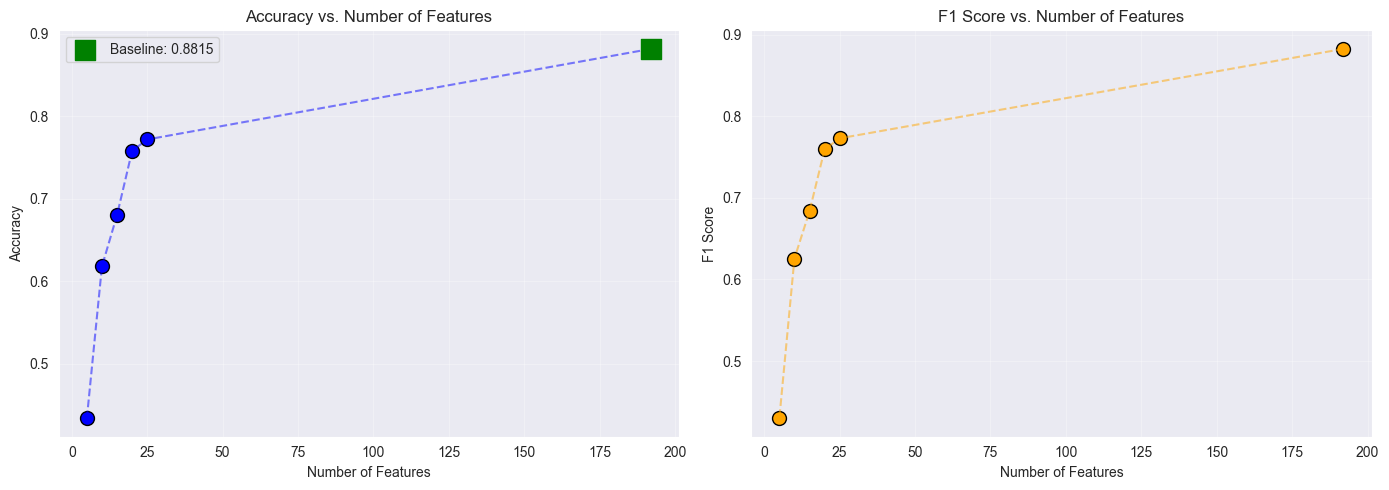

In [17]:
# Plot accuracy vs number of features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
valid = results_df[~results_df['accuracy'].isna()]
ax.scatter(valid['n_features'], valid['accuracy'], s=100, c='blue', edgecolors='black')
ax.plot(valid['n_features'], valid['accuracy'], 'b--', alpha=0.5)

# Highlight baseline and best
baseline = valid[valid['config'] == 'BASELINE'].iloc[0]
ax.scatter([baseline['n_features']], [baseline['accuracy']], s=200, c='green', marker='s', 
           label=f'Baseline: {baseline["accuracy"]:.4f}', zorder=5)

best = valid.iloc[0]
if best['config'] != 'BASELINE':
    ax.scatter([best['n_features']], [best['accuracy']], s=200, c='red', marker='*', 
               label=f'Best: {best["accuracy"]:.4f}', zorder=5)

ax.set_xlabel('Number of Features')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs. Number of Features')
ax.legend()
ax.grid(True, alpha=0.3)

# F1 Score
ax = axes[1]
ax.scatter(valid['n_features'], valid['f1'], s=100, c='orange', edgecolors='black')
ax.plot(valid['n_features'], valid['f1'], 'orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Features')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs. Number of Features')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()

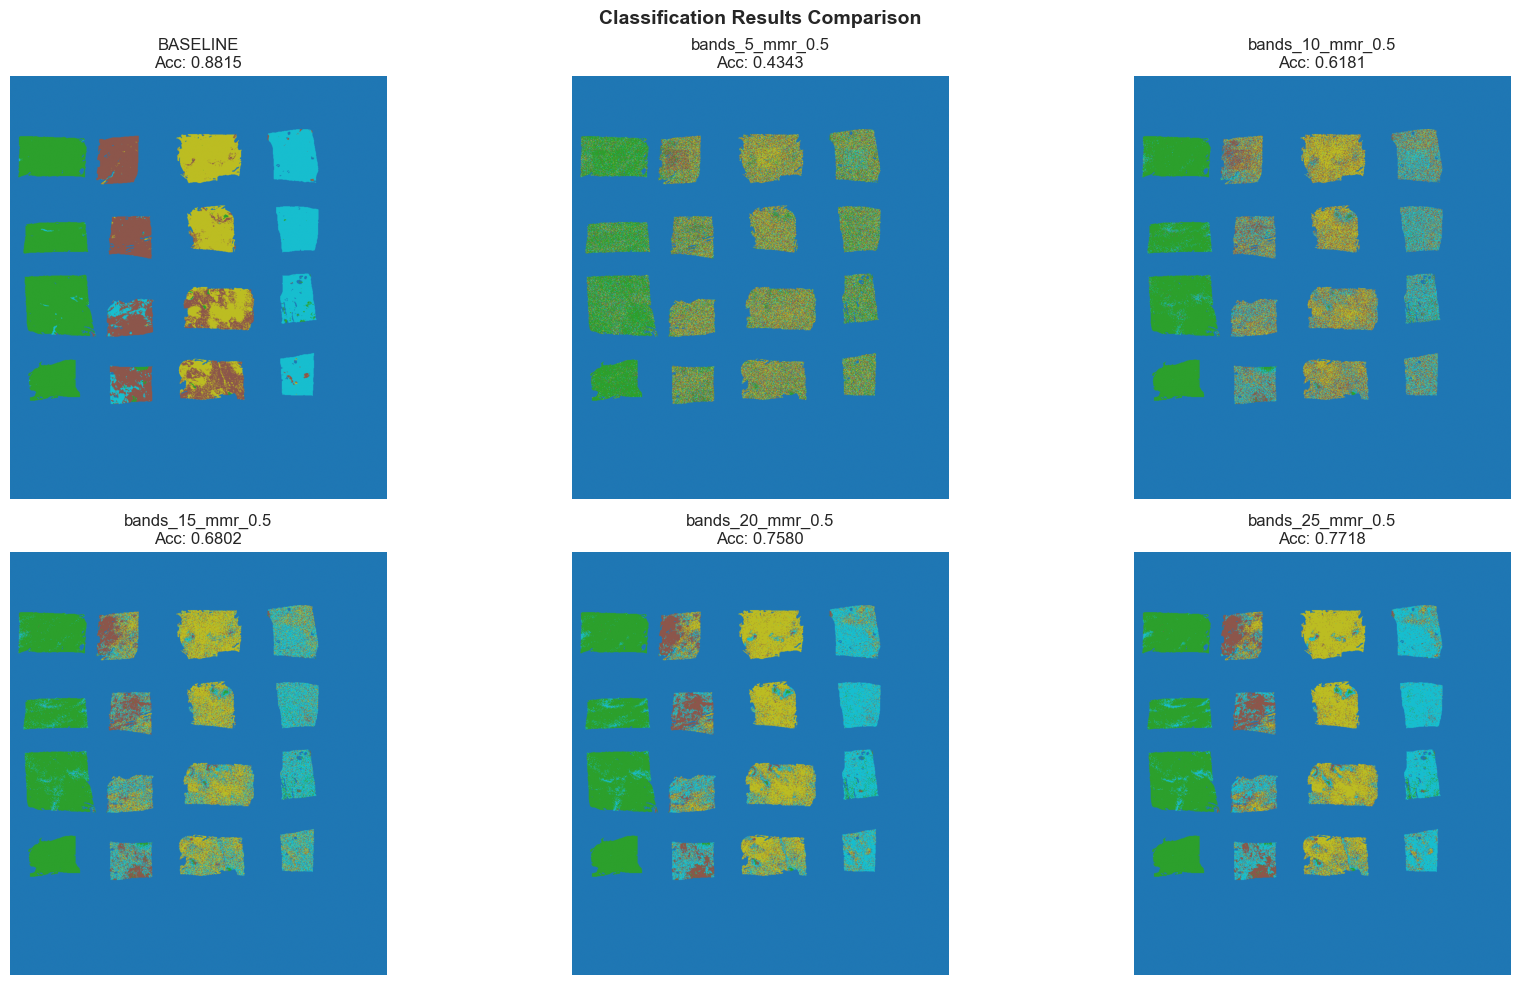

In [18]:
# Compare all classification maps
n_maps = len(all_cluster_maps)
cols = min(3, n_maps)
rows = (n_maps + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes = np.atleast_2d(axes).flatten()

for ax, (name, cmap) in zip(axes, all_cluster_maps.items()):
    result = results_df[results_df['config'] == name].iloc[0]
    acc = result['accuracy'] if 'accuracy' in result and not pd.isna(result['accuracy']) else 0
    ax.imshow(cmap, cmap='tab10')
    ax.set_title(f'{name}\nAcc: {acc:.4f}')
    ax.axis('off')

# Hide empty axes
for ax in axes[n_maps:]:
    ax.axis('off')

plt.suptitle('Classification Results Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_classifications.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [19]:
print("\n" + "="*80)
print("PIPELINE COMPLETE")
print("="*80)

valid = results_df[~results_df['accuracy'].isna()]
baseline = valid[valid['config'] == 'BASELINE'].iloc[0]
best = valid.iloc[0]

print(f"\nBaseline (full data):")
print(f"  Features: {baseline['n_features']}")
print(f"  Accuracy: {baseline['accuracy']:.4f}")
print(f"  F1: {baseline['f1']:.4f}")

print(f"\nBest configuration: {best['config']}")
print(f"  Features: {best['n_features']} ({best.get('reduction_pct', 0):.1f}% reduction)")
print(f"  Accuracy: {best['accuracy']:.4f}")
print(f"  F1: {best['f1']:.4f}")

if best['config'] != 'BASELINE':
    acc_change = (best['accuracy'] - baseline['accuracy']) / baseline['accuracy'] * 100
    print(f"  Accuracy change: {acc_change:+.2f}%")

print(f"\nResults saved to: {OUTPUT_DIR}")


PIPELINE COMPLETE

Baseline (full data):
  Features: 192
  Accuracy: 0.8815
  F1: 0.8824

Best configuration: BASELINE
  Features: 192 (0.0% reduction)
  Accuracy: 0.8815
  F1: 0.8824

Results saved to: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/results/Lichens_Dataset_1_20260129_130746
